In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/diabetes_en.csv")
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pregnancies        768 non-null    int64  
 1   glucose            768 non-null    int64  
 2   blood_pressure     768 non-null    int64  
 3   skin_thickness     768 non-null    int64  
 4   insulin            768 non-null    int64  
 5   bmi                768 non-null    float64
 6   diabetes_pedigree  768 non-null    float64
 7   age                768 non-null    int64  
 8   diabetes           768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df["diabetes"].value_counts()

,count
diabetes,
0,500
1,268


In [9]:
df.describe().round(1)

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,age,diabetes
count,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0,768.0
mean,3.8,120.9,69.1,20.5,79.8,32.0,0.5,33.2,0.3
std,3.4,32.0,19.4,16.0,115.2,7.9,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.3,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,30.5,32.0,0.4,29.0,0.0
75%,6.0,140.2,80.0,32.0,127.2,36.6,0.6,41.0,1.0
max,17.0,199.0,122.0,99.0,846.0,67.1,2.4,81.0,1.0


In [13]:
X = df.drop("diabetes", axis=1)   # all columns except the label
y = df["diabetes"]                 # the label only

print("X:", X.shape, "| y:", y.shape)

X: (768, 8) | y: (768,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Diabetes proportion -> train:", round(y_train.mean(), 3),
      "| test:", round(y_test.mean(), 3))

Train: 614 | Test: 154
Diabetes proportion -> train: 0.349 | test: 0.351


In [16]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


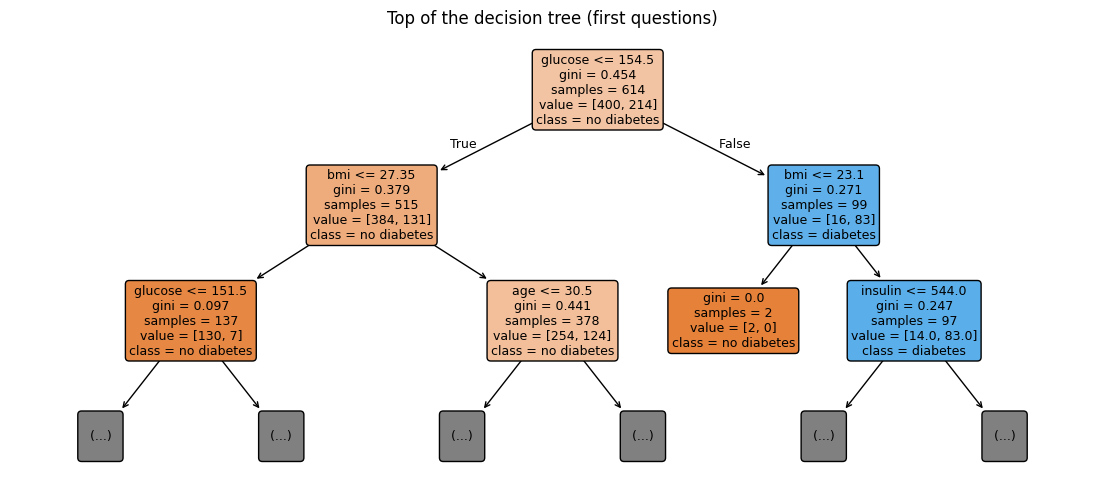

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    model,
    max_depth=2,                       # only the top, to fit the screen
    feature_names=list(X.columns),
    class_names=["no diabetes", "diabetes"],
    filled=True, rounded=True, fontsize=9, ax=ax
)
plt.title("Top of the decision tree (first questions)")
plt.show()

In [18]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predictions
}).head(10)
comparison

,actual,predicted
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,0,1


In [19]:
importance = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False)

importance.round(3)

,0
glucose,0.330
bmi,0.184
age,0.114
pregnancies,0.106
blood_pressure,0.091
diabetes_pedigree,0.090
insulin,0.059
skin_thickness,0.026


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 72.73%
